# Lab 6: Handwritten Character Recognition using Feature Extraction

**Mục tiêu:** Chuyển đổi chữ viết tay sang văn bản sử dụng các đặc trưng toán học (Euler Number, Aspect Ratio, Extent) và Cây quyết định

**Chương trình gồm các bước:**
1. Tiền xử lý ảnh (Grayscale, Binarize, Clean)
2. Phân tách ký tự (Connected Components)
3. Trích xuất đặc trưng từng ký tự
4. Phân loại OCR sử dụng Decision Tree

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy import ndimage
from skimage import measure
import os

# Setup paths
PROJECT_DIR = os.path.dirname(os.path.abspath('lab6.ipynb'))
IMAGE_DIR = os.path.join(PROJECT_DIR, 'img') if os.path.exists(os.path.join(PROJECT_DIR, 'img')) else PROJECT_DIR
TEST_IMAGE_PATH = os.path.join(PROJECT_DIR, 'test_image.png')

# Configure matplotlib
plt.style.use('default')
np.set_printoptions(precision=2, suppress=True)

## 1. Hàm tải và hiển thị ảnh (Helper Functions)

In [9]:
def load_image(path):
    """
    Tải ảnh từ file.
    
    Args:
        path (str): Đường dẫn tới file ảnh
        
    Returns:
        np.ndarray: Ảnh dưới dạng numpy array (BGR format từ OpenCV)
    """
    if not os.path.exists(path):
        raise FileNotFoundError(f"Không tìm thấy file ảnh: {path}")
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"Không thể đọc file ảnh: {path}")
    return img


def imread_gray(path):
    """
    Tải ảnh grayscale từ file.
    
    Args:
        path (str): Đường dẫn tới file ảnh
        
    Returns:
        np.ndarray: Ảnh grayscale (2D array)
    """
    img = load_image(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)


def save_image(path, img):
    """
    Lưu ảnh vào file.
    
    Args:
        path (str): Đường dẫn file đích
        img (np.ndarray): Ảnh cần lưu
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    cv2.imwrite(path, img)
    print(f"✓ Ảnh đã lưu: {path}")


def show_image(img, title="Ảnh", cmap='gray'):
    """
    Hiển thị ảnh đơn.
    
    Args:
        img (np.ndarray): Ảnh cần hiển thị
        title (str): Tiêu đề của hình vẽ
        cmap (str): Colormap ('gray', 'viridis', v.v.)
    """
    plt.figure(figsize=(8, 6))
    if len(img.shape) == 3 and img.shape[2] == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap=cmap)
    plt.title(title, fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def show_images_side_by_side(img1, img2, title1="Ảnh 1", title2="Ảnh 2"):
    """
    Hiển thị hai ảnh cạnh nhau.
    
    Args:
        img1, img2 (np.ndarray): Hai ảnh cần so sánh
        title1, title2 (str): Tiêu đề cho từng ảnh
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    if len(img1.shape) == 3 and img1.shape[2] == 3:
        axes[0].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
    else:
        axes[0].imshow(img1, cmap='gray')
    axes[0].set_title(title1)
    axes[0].axis('off')
    
    if len(img2.shape) == 3 and img2.shape[2] == 3:
        axes[1].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
    else:
        axes[1].imshow(img2, cmap='gray')
    axes[1].set_title(title2)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

print("✓ Helper functions loaded")

✓ Helper functions loaded


## 2. Hàm tiền xử lý ảnh (Preprocessing)

In [10]:
def remove_small_components(binary_img, min_area=30, connectivity=8):
    """
    Loại bỏ các connected components có diện tích nhỏ hơn ngưỡng.

    Args:
        binary_img (np.ndarray): Ảnh nhị phân 0/255, chữ là vùng trắng.
        min_area (int): Diện tích nhỏ nhất để giữ lại.
        connectivity (int): Mức liên thông cho connected components.

    Returns:
        tuple[np.ndarray, int]: Ảnh đã lọc và số thành phần được giữ lại.
    """
    binary_mask = (binary_img > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
        binary_mask, connectivity=connectivity
    )

    cleaned = np.zeros_like(binary_img, dtype=np.uint8)
    kept_count = 0

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area:
            cleaned[labels == label] = 255
            kept_count += 1

    return cleaned, kept_count


def preprocess_image(img_path, min_area=15, close_kernel_size=3, use_adaptive=False):
    """
    Tiền xử lý ảnh: Grayscale -> Làm mượt nhẹ -> Threshold -> Làm kín nét chữ -> Lọc nhiễu nhỏ.

    Tương đương MATLAB:
        img = imread(path)
        img_gray = rgb2gray(img)
        img_bw = ~imbinarize(img_gray)
        img_clean = bwareaopen(img_bw, 30)

    Args:
        img_path (str): Đường dẫn tới file ảnh gốc
        min_area (int): Kích thước tối thiểu của các vật thể (pixel²)
        close_kernel_size (int): Kích thước kernel cho phép toán đóng
        use_adaptive (bool): Dùng adaptive threshold thay cho Otsu khi ảnh không đều sáng

    Returns:
        dict: {
            'original': ảnh gốc (BGR),
            'gray': ảnh grayscale,
            'binary': ảnh nhị phân,
            'cleaned': ảnh sau khi dọn rác,
            'removed_small_components': số thành phần nhỏ đã loại bỏ
        }
    """
    img = load_image(img_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_smooth = cv2.GaussianBlur(img_gray, (3, 3), 0)

    if use_adaptive:
        img_binary = cv2.adaptiveThreshold(
            img_smooth,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            31,
            11,
        )
    else:
        _, img_binary = cv2.threshold(
            img_smooth,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU,
        )

    img_binary_inv = 255 - img_binary

    if close_kernel_size and close_kernel_size > 1:
        kernel = cv2.getStructuringElement(
            cv2.MORPH_RECT,
            (close_kernel_size, close_kernel_size),
        )
        img_closed = cv2.morphologyEx(img_binary_inv, cv2.MORPH_CLOSE, kernel, iterations=1)
    else:
        img_closed = img_binary_inv.copy()

    img_cleaned, kept_count = remove_small_components(
        img_closed,
        min_area=min_area,
        connectivity=8,
    )

    return {
        'original': img,
        'gray': img_gray,
        'binary': img_binary,
        'cleaned': img_cleaned,
        'removed_small_components': kept_count,
    }


print("✓ Preprocessing functions loaded")

✓ Preprocessing functions loaded


## 3. Hàm trích xuất các đặc trưng (Feature Extraction)

In [11]:
def extract_components(img_binary, min_width=2, min_height=8):
    """
    Tách các ký tự thành connected components (tương đương bwconncomp + regionprops).
    
    Args:
        img_binary (np.ndarray): Ảnh nhị phân (0-255)
        min_width (int): Chiều rộng tối thiểu
        min_height (int): Chiều cao tối thiểu
        
    Returns:
        list: Danh sách các thành phần, mỗi thành phần chứa:
              {
                'bbox': (x, y, width, height),
                'euler_number': số Euler,
                'extent': độ đặc,
                'centroid': (cx, cy),
                'area': diện tích,
                'label': nhãn connected component
              }
    """
    # Connected Components Analysis
    labeled = measure.label(img_binary > 128)
    num_objects = labeled.max()
    
    components = []
    
    for i in range(1, num_objects + 1):
        component_mask = (labeled == i).astype(np.uint8)
        
        # Tìm bounding box
        rows = np.any(component_mask, axis=1)
        cols = np.any(component_mask, axis=0)
        
        if not rows.any() or not cols.any():
            continue
        
        y_min, y_max = np.where(rows)[0][[0, -1]]
        x_min, x_max = np.where(cols)[0][[0, -1]]
        
        width = x_max - x_min + 1
        height = y_max - y_min + 1
        
        # Lọc theo kích thước tối thiểu
        if width < min_width or height < min_height:
            continue
        
        # Tính các đặc trưng
        area = component_mask.sum()
        
        # Centroid (trọng tâm)
        coords = np.where(component_mask)
        cy = coords[0].mean()  # Y coordinate
        cx = coords[1].mean()  # X coordinate
        
        # Extent: tỷ lệ giữa diện tích object và bounding box
        bbox_area = width * height
        extent = area / bbox_area if bbox_area > 0 else 0
        
        # Euler Number (số lỗ hổng)
        # Tính bằng: χ = 1 - holes = connected_components - holes
        # Sử dụng morphological operations để tính
        euler = measure.euler_number(component_mask)
        holes = 1 - euler  # Số lỗ hổng
        
        components.append({
            'bbox': (x_min, y_min, width, height),
            'euler_number': euler,
            'holes': holes,
            'extent': extent,
            'centroid': (cx, cy),
            'area': area,
            'label': i
        })
    
    # Sắp xếp theo vị trí x (từ trái sang phải)
    components.sort(key=lambda c: c['bbox'][0])
    
    return components


print("✓ Feature extraction functions loaded")

✓ Feature extraction functions loaded


## 4. OCR Classifier: Cây quyết định (Decision Tree)

In [12]:
def choose_best_ambiguous_character(component):
    """
    Chọn 1 ký tự tốt nhất cho nhóm mơ hồ S/E/C/H bằng heuristic scoring.
    
    Hàm này không cần dữ liệu huấn luyện; nó chỉ dùng các đặc trưng sẵn có
    để ưu tiên ký tự có hình dáng phù hợp nhất với component hiện tại.
    """
    bbox = component['bbox']
    width = bbox[2]
    height = bbox[3]
    cy = component['centroid'][0]
    extent = component['extent']
    holes = component['holes']
    
    aspect_ratio = width / height if height > 0 else 0
    bb_cy = bbox[1] + height / 2
    y_offset = (cy - bb_cy) / height if height > 0 else 0
    
    def bell_score(value, target, tolerance):
        if tolerance <= 0:
            return 0.0
        return max(0.0, 1.0 - abs(value - target) / tolerance)
    
    candidate_scores = {
        'S': (
            0.40 * bell_score(aspect_ratio, 0.75, 0.40)
            + 0.35 * bell_score(extent, 0.45, 0.20)
            + 0.25 * bell_score(abs(y_offset), 0.00, 0.12)
        ),
        'E': (
            0.45 * bell_score(aspect_ratio, 0.55, 0.25)
            + 0.35 * bell_score(extent, 0.55, 0.20)
            + 0.20 * bell_score(y_offset, -0.03, 0.10)
        ),
        'C': (
            0.45 * bell_score(aspect_ratio, 0.70, 0.35)
            + 0.35 * bell_score(extent, 0.35, 0.18)
            + 0.20 * bell_score(holes, 0.0, 1.0)
        ),
        'H': (
            0.45 * bell_score(aspect_ratio, 0.80, 0.30)
            + 0.35 * bell_score(extent, 0.50, 0.18)
            + 0.20 * bell_score(abs(y_offset), 0.00, 0.10)
        ),
    }
    
    return max(candidate_scores, key=candidate_scores.get)


def classify_character(component):
    """
    Phân loại ký tự sử dụng Cây quyết định dựa trên các đặc trưng.
    
    Decision Tree V2.0 (Nâng cấp):
    - Dùng số lỗ hổng (Holes) làm nút gốc
    - Dùng Y-offset (độ lệch trọng tâm theo trục Y)
    - Dùng Extent (độ đặc của hình dạng)
    - Dùng Aspect Ratio (tỷ lệ chiều rộng/cao)
    
    Args:
        component (dict): Thành phần ký tự với các đặc trưng
        
    Returns:
        str: Ký tự được dự đoán (A, B, D, E, H, I, M, O, P, S, T, W, hoặc '?')
    """
    bbox = component['bbox']
    width = bbox[2]
    height = bbox[3]
    cy = component['centroid'][0]
    holes = component['holes']
    extent = component['extent']
    
    # Aspect Ratio
    aspect_ratio = width / height if height > 0 else 0
    
    # Y-offset chuẩn hóa: (Centroid_Y - BBox_Center_Y) / height
    # Âm = Lệch lên trên, Dương = Lệch xuống dưới
    bb_cy = bbox[1] + height / 2
    y_offset = (cy - bb_cy) / height if height > 0 else 0
    
    # === DECISION TREE ===
    if holes == 2:
        predicted_char = 'B'
    
    elif holes == 1:
        # Nhóm 1 lỗ hổng: {A, D, O, P, R}
        if y_offset < -0.06:
            predicted_char = 'P'  # Phần bầu ở trên
        elif y_offset > 0.05:
            predicted_char = 'A'  # Chân bành ra dưới
        else:
            # Trọng tâm ở giữa: phân biệt D vs O
            if extent > 0.65:
                predicted_char = 'D'  # D rất lấp đầu khung
            else:
                predicted_char = 'O'  # O tròn, Extent thấp
    
    elif holes == 0:
        # Nhóm 0 lỗ hổng
        if aspect_ratio < 0.35:
            predicted_char = 'I'  # Hẹp và dài
        elif aspect_ratio > 1.1:
            predicted_char = 'M'  # Ngang, hoặc W
        else:
            # Thử tách chữ T
            if y_offset < -0.1:
                predicted_char = 'T'  # Gạch ngang ở trên
            else:
                predicted_char = choose_best_ambiguous_character(component)
    
    else:
        # Holes > 2 hoặc < 0 (hiếm)
        predicted_char = '?'
    
    return predicted_char


def classify_all_characters(components):
    """
    Phân loại toàn bộ các ký tự trong ảnh.
    
    Args:
        components (list): Danh sách các thành phần
        
    Returns:
        str: Chuỗi ký tự được nhận dạng
    """
    recognized_text = ''
    for comp in components:
        char = classify_character(comp)
        recognized_text += char
    return recognized_text


print("OCR Classifier loaded")

OCR Classifier loaded


## 5. Hàm hiển thị kết quả (Visualization)

In [13]:
def visualize_preprocessing(img_dict):
    """
    Hiển thị các bước tiền xử lý.
    
    Args:
        img_dict (dict): Kết quả từ preprocess_image()
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Ảnh gốc
    axes[0, 0].imshow(cv2.cvtColor(img_dict['original'], cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    # Grayscale
    axes[0, 1].imshow(img_dict['gray'], cmap='gray')
    axes[0, 1].set_title('Grayscale', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    # Binary
    axes[1, 0].imshow(img_dict['binary'], cmap='gray')
    axes[1, 0].set_title('Binary', fontsize=12, fontweight='bold')
    axes[1, 0].axis('off')
    
    # Cleaned
    axes[1, 1].imshow(img_dict['cleaned'], cmap='gray')
    axes[1, 1].set_title('Cleaned', fontsize=12, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    plt.show()


def visualize_components_features(img_original, img_binary, components):
    """
    Hiển thị Bounding Box và các đặc trưng của từng ký tự.
    
    Args:
        img_original (np.ndarray): Ảnh gốc
        img_binary (np.ndarray): Ảnh nhị phân
        components (list): Danh sách các thành phần
    """
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Hiển thị ảnh nhị phân
    ax.imshow(img_binary, cmap='gray')
    ax.set_title('Bounding Box và Số lỗ hổng (Holes) trên từng ký tự', 
                 fontsize=13, fontweight='bold')
    
    # Vẽ bounding box và chú thích số lỗ hổng
    for comp in components:
        x, y, w, h = comp['bbox']
        holes = comp['holes']
        
        # Vẽ Bounding Box (màu xanh lá cây)
        rect = Rectangle((x, y), w, h, linewidth=1.5, 
                        edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        
        # In số lỗ hổng phía trên (màu vàng)
        ax.text(x, y - 6, f'Lỗ:{int(holes)}', 
               color='yellow', fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def visualize_ocr_results(img_original, components):
    """
    Hiển thị kết quả phân loại OCR: vẽ bounding box và ký tự được dự đoán.
    
    Args:
        img_original (np.ndarray): Ảnh gốc (BGR)
        components (list): Danh sách các thành phần
    """
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Chuyển BGR sang RGB để hiển thị
    img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title('OCR', 
                fontsize=13, fontweight='bold')
    
    recognized_text = ''
    
    # Vẽ các bounding box và dự đoán
    for comp in components:
        x, y, w, h = comp['bbox']
        predicted_char = classify_character(comp)
        recognized_text += predicted_char
        
        # Vẽ Bounding Box (màu vàng)
        rect = Rectangle((x, y), w, h, linewidth=1, 
                        edgecolor='yellow', facecolor='none')
        ax.add_patch(rect)
        
        # In ký tự được dự đoán (màu cyan)
        ax.text(x, y - 10, predicted_char, 
               color='cyan', fontsize=12, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.8))
    
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    return recognized_text


print("Visualization functions loaded")

Visualization functions loaded


## 6. Pipeline chính: Chạy OCR trên ảnh test

Test image path: d:\Code_learning\imageProcessing\lab6\test_image.png
File exists: True

 Tìm thấy file ảnh test

Tiền xử lý ảnh
Hoàn tất tiền xử lý ảnh


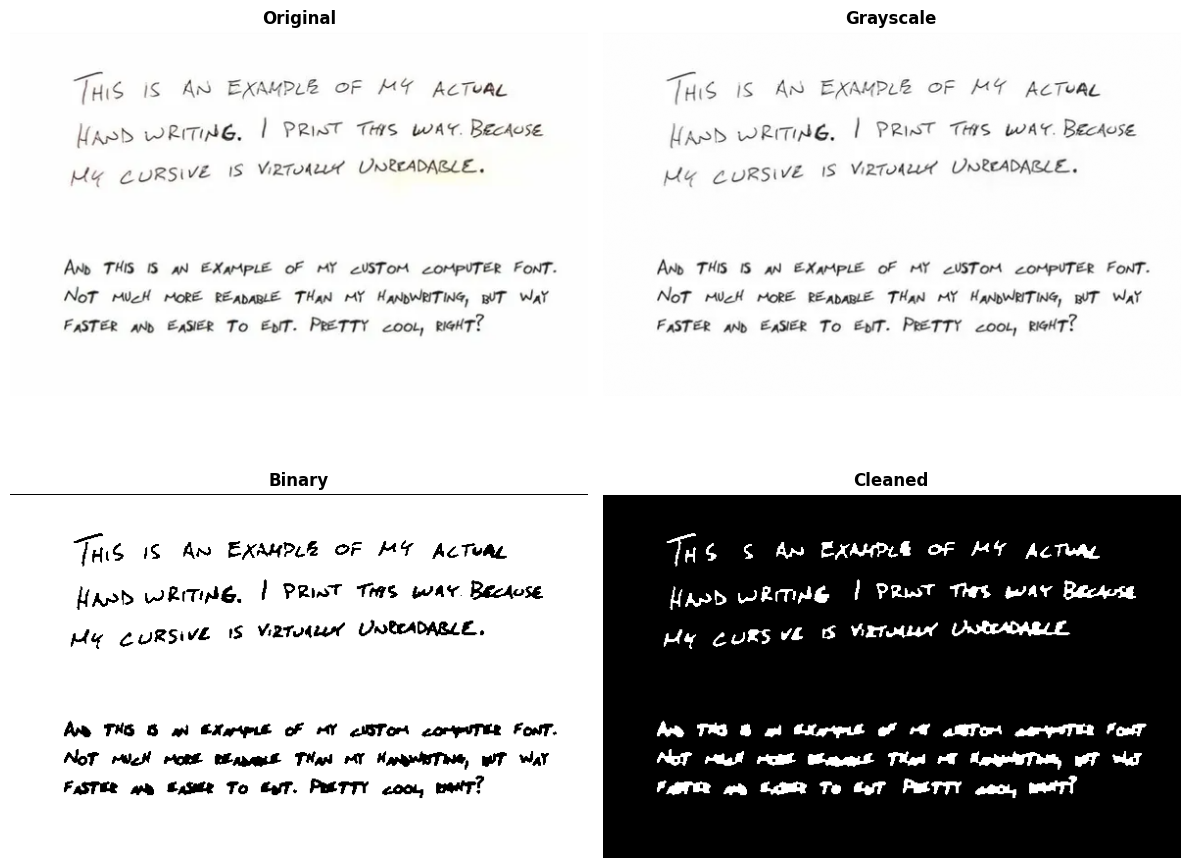


Connected Components
Tìm thấy 74 ký tự

Chiết tiết các ký tự:
--------------------------------------------------------------------------------
#    Position        Size         Holes    Extent     Y-Offset  
--------------------------------------------------------------------------------
1    ( 55,232)       28x 17     0        0.498         -10.147
2    ( 55,261)       36x 17     2        0.435         -11.595
3    ( 55,293)       10x 12     0        0.533         -20.022
4    ( 62,139)       19x 18     0        0.327          -4.277
5    ( 64,294)       46x 14     1        0.607         -15.317
6    ( 65, 41)       30x 34     0        0.148           0.592
7    ( 68, 95)       13x 24     0        0.337          -1.389
8    ( 83,143)       12x 16     0        0.396          -3.946
9    ( 84, 55)       11x 16     0        0.455           1.619
10   ( 84,102)       27x 14     0        0.384          -0.926
11   ( 96,234)       31x 14     1        0.608          -9.206
12   (104,263)   

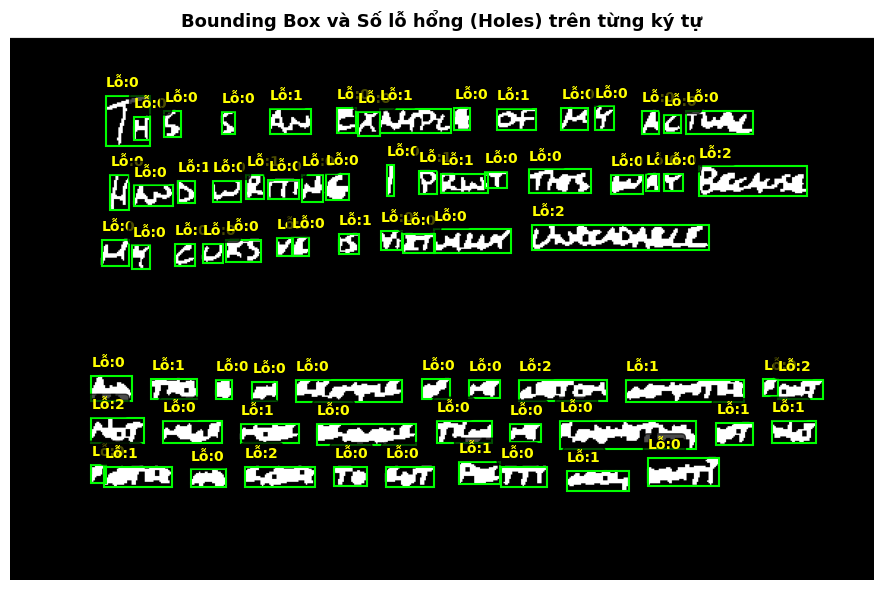


Decision Tree


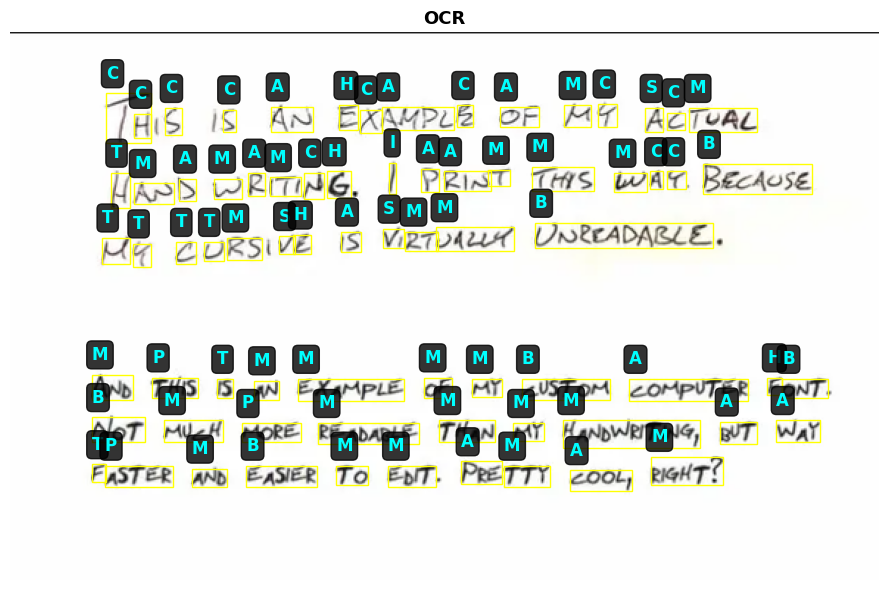

In [14]:
# Kiểm tra file ảnh test có tồn tại không
print(f"Test image path: {TEST_IMAGE_PATH}")
print(f"File exists: {os.path.exists(TEST_IMAGE_PATH)}")

if not os.path.exists(TEST_IMAGE_PATH):
    print(f"\n Cảnh báo: Không tìm thấy {TEST_IMAGE_PATH}")
    print("Hãy đảm bảo file 'test_image.png' nằm trong thư mục lab6")
else:
    print(f"\n Tìm thấy file ảnh test\n")
    
    # Bước 1: Tiền xử lý ảnh
    print("=" * 60)
    print("Tiền xử lý ảnh")
    print("=" * 60)
    
    img_dict = preprocess_image(TEST_IMAGE_PATH, min_area=30)
    print("Hoàn tất tiền xử lý ảnh")
    
    # Hiển thị các bước tiền xử lý
    visualize_preprocessing(img_dict)
    
    # Bước 2: Phân tách ký tự (Connected Components Analysis)
    print("\n" + "=" * 60)
    print("Connected Components")
    print("=" * 60)
    
    components = extract_components(img_dict['cleaned'], min_width=2, min_height=8)
    print(f"Tìm thấy {len(components)} ký tự")
    
    # In chi tiết các thành phần
    print("\nChiết tiết các ký tự:")
    print("-" * 80)
    print(f"{'#':<4} {'Position':<15} {'Size':<12} {'Holes':<8} {'Extent':<10} {'Y-Offset':<10}")
    print("-" * 80)
    
    for i, comp in enumerate(components):
        x, y, w, h = comp['bbox']
        cy = comp['centroid'][0]
        bb_cy = y + h / 2
        y_offset = (cy - bb_cy) / h if h > 0 else 0
        
        print(f"{i+1:<4} ({x:3d},{y:3d})      {w:3d}x{h:3d}     {int(comp['holes']):<8} {comp['extent']:<10.3f} {y_offset:>10.3f}")
    
    # Bước 3: Hiển thị các đặc trưng
    print("\n" + "=" * 60)
    print("ĐẶC TRƯNG TRÊN ẢNH NHỊ PHÂN")
    print("=" * 60)
    
    visualize_components_features(img_dict['original'], img_dict['cleaned'], components)
    
    # Bước 4: OCR và hiển thị kết quả
    print("\n" + "=" * 60)
    print("Decision Tree")
    print("=" * 60)
    
    recognized_text = visualize_ocr_results(img_dict['original'], components)